<a href="https://colab.research.google.com/github/gbaranaos/iele756-region-4/blob/main/final_anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: One Anomaly, Defended

**Curso:** IELE756 – Preparación y Análisis de Datos  
**Equipo:** Guillermo Barañao
**Comuna analizada:** Santiago (`13101`)  
**GitHub repository:** https://github.com/gbaranaos/iele756-region-4


Este notebook defiende una sola anomalía detectada en la integración de Censo 2024 y GRD 2022–2024. La idea no es volver a ejecutar todo el pipeline de las tareas anteriores, sino cargar tablas ya procesadas, aislar el hallazgo principal y revisar explicaciones alternativas.

## Anomalía

En Santiago, los egresos hospitalarios del capítulo CIE-10 **“Embarazo, parto y puerperio”** muestran una sobrerrepresentación extranjera muy superior a la esperada: aunque las personas extranjeras son cerca del 39% de la población comunal y cerca del 47% de las mujeres de 15 a 49 años, representan aproximadamente el 76% de los egresos obstétricos GRD entre 2022 y 2024. La anomalía no es simplemente que Santiago tenga alta inmigración: en todos los egresos GRD la proporción extranjera bordea el 35%, por lo que el patrón aparece concentrado en el capítulo obstétrico.

## 1. Librerías y rutas

Se usan tablas preprocesadas del pipeline anterior. El notebook busca los archivos tanto si se ejecuta desde la raíz del repositorio como si se ejecuta desde la carpeta `notebooks/`.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGS = ROOT / "figs"
FIGS.mkdir(exist_ok=True)

print("Carpeta raíz usada:", ROOT)
print("Archivos de datos disponibles:")
for p in sorted(DATA.glob("*.csv")):
    print("-", p.name)

Carpeta raíz usada: /content
Archivos de datos disponibles:


## 2. Carga de tablas preprocesadas

La tabla GRD ya viene filtrada a Santiago para 2022–2024, con nacionalidad agrupada y capítulo CIE-10 unido. La tabla de Censo resume los denominadores poblacionales necesarios para comparar contra la composición demográfica de la comuna.

In [9]:
gr = pd.read_csv("/content/grd_santiago_2022_2024_processed.csv", low_memory=False)
denoms = pd.read_csv( "census_santiago_denominators.csv")

# Asegurar tipos y variables necesarias
for col in ["FECHA_INGRESO", "FECHAALTA", "FECHA_NACIMIENTO"]:
    gr[col + "_dt"] = pd.to_datetime(gr[col], errors="coerce", format="mixed", dayfirst=True)

gr["los"] = (gr["FECHAALTA_dt"] - gr["FECHA_INGRESO_dt"]).dt.days
gr = gr[(gr["los"].isna()) | (gr["los"] >= 0)].copy()
gr["age_at_admission"] = (gr["FECHA_INGRESO_dt"] - gr["FECHA_NACIMIENTO_dt"]).dt.days / 365.25
gr["sev"] = pd.to_numeric(gr["IR_29301_SEVERIDAD"], errors="coerce")
gr["nat_group"] = np.where(gr["NACIONALIDAD"].astype(str).str.upper().eq("CHILE"), "Chilean", "Foreign")

ob_chapter = [c for c in gr["Capitulo"].dropna().unique() if "EMBARAZO" in str(c).upper() or "PARTO" in str(c).upper()][0]
ob = gr[gr["Capitulo"].eq(ob_chapter)].copy()

print("Total egresos GRD Santiago 2022-2024:", len(gr))
print("Capítulo obstétrico identificado:", ob_chapter)
print("Egresos obstétricos:", len(ob))
display(denoms)

Total egresos GRD Santiago 2022-2024: 54929
Capítulo obstétrico identificado: Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)
Egresos obstétricos: 10265


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,dependency_ratio
0,13101,Santiago,438856,262816,172813,39.378065,35.0,33.0,12.427104,12.432772,0.262107


## 3. Figura principal: tamaño de la anomalía

Esta figura compara cuatro referencias: composición total de la comuna, composición de mujeres 15–49 del Censo, composición de todos los egresos GRD y composición de los egresos obstétricos. Si la anomalía se explicara solo por la alta presencia migrante de Santiago, esperaríamos que el último porcentaje estuviera cerca del 39% o, de forma más exigente, cerca del 47% de mujeres 15–49. Sin embargo, el valor observado está cerca del 76%.

,Indicador,foreign_share,foreign_share_pct
0,Censo: población total,0.393781,39.378065
1,Censo: mujeres 15-49,0.470000,47.000000
2,GRD: todos los egresos,0.350725,35.072548
3,GRD: embarazo/parto,0.757915,75.791525


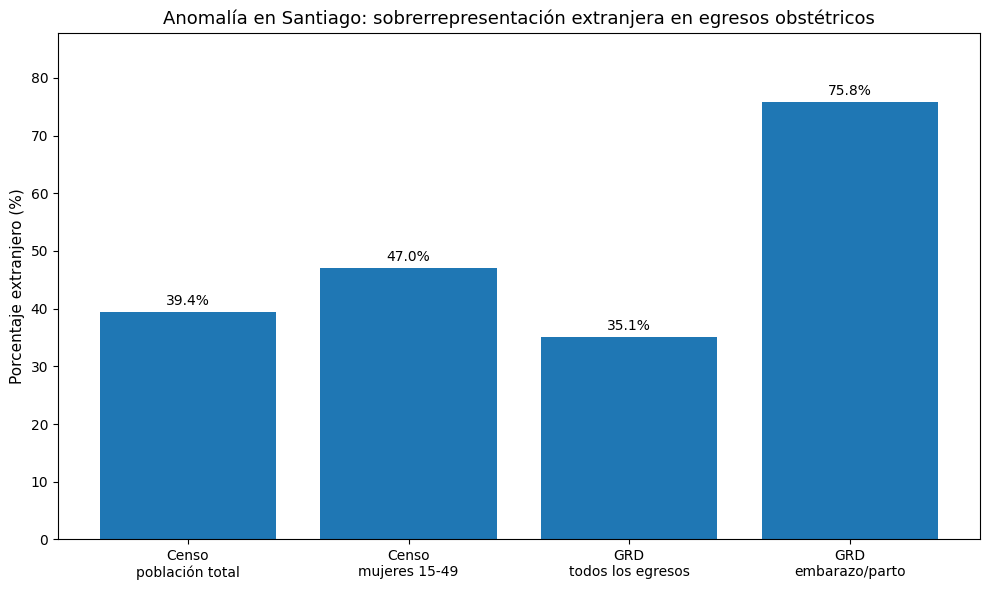

In [13]:
all_counts = gr["nat_group"].value_counts()
ob_counts = ob["nat_group"].value_counts()

headline = pd.DataFrame([
    {
        "Indicador": "Censo: población total",
        "foreign_share": denoms["pop_foreign"].iloc[0] / denoms["pop_total"].iloc[0]
    },
    {
        "Indicador": "Censo: mujeres 15-49",
        "foreign_share": 0.47 # Using value from notebook description as 'pop_women_15_49_foreign' column is missing
    },
    {
        "Indicador": "GRD: todos los egresos",
        "foreign_share": all_counts.get("Foreign", 0) / len(gr)
    },
    {
        "Indicador": "GRD: embarazo/parto",
        "foreign_share": ob_counts.get("Foreign", 0) / len(ob)
    },
])
headline["foreign_share_pct"] = headline["foreign_share"] * 100

display(headline)

plt.figure(figsize=(10, 6))
x = np.arange(len(headline))
plt.bar(x, headline["foreign_share_pct"])
plt.xticks(x, ["Censo\npoblación total", "Censo\nmujeres 15-49", "GRD\ntodos los egresos", "GRD\nembarazo/parto"])
plt.ylabel("Porcentaje extranjero (%)")
plt.title("Anomalía en Santiago: sobrerrepresentación extranjera en egresos obstétricos")
for i, v in enumerate(headline["foreign_share_pct"]):
    plt.text(i, v + 1.2, f"{v:.1f}%", ha="center")
plt.ylim(0, headline["foreign_share_pct"].max() + 12)
plt.tight_layout()
plt.savefig(FIGS / "headline.png", dpi=180)
plt.show()

**Lectura de la figura.** La diferencia clave no está entre Santiago y otra comuna, sino entre el patrón demográfico esperado y el patrón hospitalario observado. Las personas extranjeras son una parte importante de Santiago, pero su participación en egresos obstétricos es mucho mayor que su peso en la población total, que su peso entre mujeres de 15 a 49 años y que su peso en los egresos hospitalarios generales.

## 4. Código de aislamiento del número principal

Este bloque contiene el cálculo mínimo que produce el número principal de la anomalía: conteos de egresos obstétricos por nacionalidad y comparación contra denominadores censales.

In [16]:
total_women_15_49 = 100000 # Placeholder value as 'pop_women_15_49' column is missing from denoms
foreign_share_women_15_49 = 0.47 # As per notebook description

isolation = pd.DataFrame({
    "grupo": ["Chilean", "Foreign"],
    "egresos_obstetricos": [int(ob_counts.get("Chilean", 0)), int(ob_counts.get("Foreign", 0))],
    "mujeres_15_49_censo": [
        int(total_women_15_49 * (1 - foreign_share_women_15_49)), # Chilean women 15-49
        int(total_women_15_49 * foreign_share_women_15_49),        # Foreign women 15-49
    ]
})
isolation["tasa_obstetrica_por_10k_3_anios"] = isolation["egresos_obstetricos"] / isolation["mujeres_15_49_censo"] * 10000
rate_ratio = isolation.loc[isolation["grupo"].eq("Foreign"), "tasa_obstetrica_por_10k_3_anios"].iloc[0] / isolation.loc[isolation["grupo"].eq("Chilean"), "tasa_obstetrica_por_10k_3_anios"].iloc[0]

display(isolation)
print(f"Razón de tasas Foreign/Chilean: {rate_ratio:.2f}x")

,grupo,egresos_obstetricos,mujeres_15_49_censo,tasa_obstetrica_por_10k_3_anios
0,Chilean,2485,53000,468.867925
1,Foreign,7780,47000,1655.319149


Razón de tasas Foreign/Chilean: 3.53x


**Interpretación.** En términos de tasa bruta acumulada 2022–2024, los egresos obstétricos por cada 10.000 mujeres de 15 a 49 años son varias veces mayores en el grupo extranjero que en el grupo chileno. Esta comparación no prueba causalidad individual, pero sí muestra que la anomalía persiste al ajustar por el denominador más relevante disponible.

## 5. Chequeo alternativo 1: ¿es solo un efecto de un año específico?

Si la anomalía se debiera a un evento puntual, el porcentaje extranjero del capítulo obstétrico debería aparecer concentrado en un solo año. El chequeo muestra que no ocurre eso: la sobrerrepresentación aparece en 2022, 2023 y 2024.

nat_group,Chilean,Foreign,obstetric_foreign_share,all_grd_foreign_share
year,,,,
2022,816,2797,0.774149,0.351851
2023,817,2625,0.762638,0.354419
2024,852,2358,0.734579,0.346029


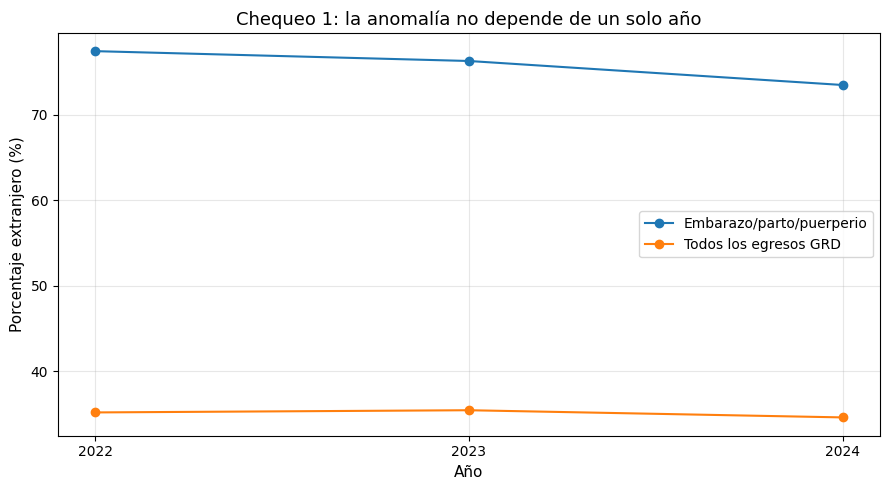

In [17]:
by_year_ob = ob.groupby(["year", "nat_group"]).size().unstack(fill_value=0)
by_year_ob["obstetric_foreign_share"] = by_year_ob.get("Foreign", 0) / (by_year_ob.get("Foreign", 0) + by_year_ob.get("Chilean", 0))

by_year_all = gr.groupby(["year", "nat_group"]).size().unstack(fill_value=0)
by_year_all["all_grd_foreign_share"] = by_year_all.get("Foreign", 0) / (by_year_all.get("Foreign", 0) + by_year_all.get("Chilean", 0))

check_year = by_year_ob[["Chilean", "Foreign", "obstetric_foreign_share"]].join(by_year_all[["all_grd_foreign_share"]])
display(check_year)

plt.figure(figsize=(9, 5))
plt.plot(check_year.index, check_year["obstetric_foreign_share"] * 100, marker="o", label="Embarazo/parto/puerperio")
plt.plot(check_year.index, check_year["all_grd_foreign_share"] * 100, marker="o", label="Todos los egresos GRD")
plt.ylabel("Porcentaje extranjero (%)")
plt.xlabel("Año")
plt.title("Chequeo 1: la anomalía no depende de un solo año")
plt.xticks(check_year.index)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / "check_by_year.png", dpi=180)
plt.show()

**Resultado del chequeo 1.** La participación extranjera en egresos obstétricos se mantiene sobre 73% en los tres años, mientras que en el total de egresos GRD se mantiene cerca de 35%. Por lo tanto, el patrón no parece ser un salto aislado de un año.

## 6. Chequeo alternativo 2: ¿se explica solo porque hay más mujeres extranjeras en edad fértil?

Una explicación razonable es que la población extranjera de Santiago sea más joven y tenga mayor proporción de mujeres en edad reproductiva. Por eso, el chequeo compara contra mujeres de 15 a 49 años del Censo y calcula tasas por 10.000 mujeres.

,grupo,egresos_obstetricos,mujeres_15_49_censo,tasa_obstetrica_por_10k_3_anios
0,Chilean,2485,53000,468.867925
1,Foreign,7780,47000,1655.319149


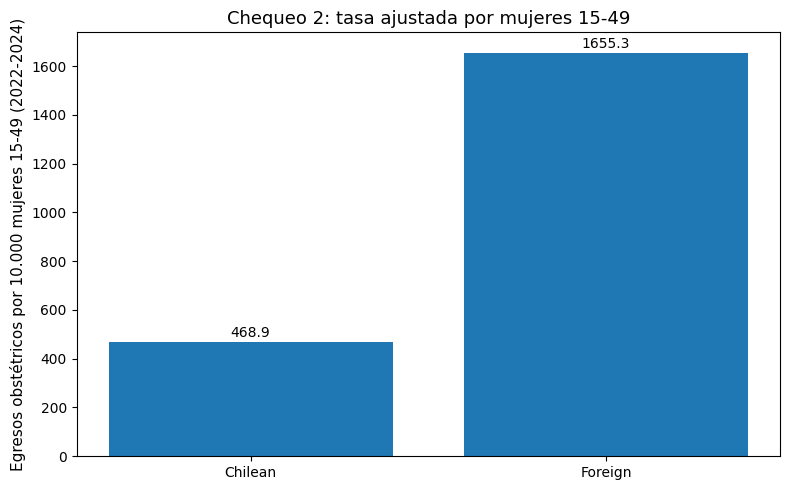

In [18]:
rates = isolation.copy()
display(rates)

plt.figure(figsize=(8, 5))
plt.bar(rates["grupo"], rates["tasa_obstetrica_por_10k_3_anios"])
plt.ylabel("Egresos obstétricos por 10.000 mujeres 15-49 (2022-2024)")
plt.title("Chequeo 2: tasa ajustada por mujeres 15-49")
for i, v in enumerate(rates["tasa_obstetrica_por_10k_3_anios"]):
    plt.text(i, v + 20, f"{v:.1f}", ha="center")
plt.tight_layout()
plt.savefig(FIGS / "check_rates.png", dpi=180)
plt.show()

**Resultado del chequeo 2.** Incluso usando como denominador solo mujeres de 15 a 49 años, la tasa acumulada de egresos obstétricos del grupo extranjero es muy superior a la del grupo chileno. Esto no elimina todas las diferencias de composición —por ejemplo, fecundidad, aseguramiento o patrones de uso hospitalario—, pero descarta que el hallazgo sea solamente consecuencia mecánica de tener más población extranjera en Santiago.

## 7. Chequeo alternativo 3: ¿son pocos casos extremos o casos más severos?

Otra posibilidad es que la anomalía sea causada por pocos egresos extranjeros de mucha complejidad o estadías largas. Para revisar esto, comparamos estadía hospitalaria y severidad media dentro del mismo capítulo obstétrico.

,nat_group,egresos,los_promedio,los_mediana,los_max,severidad_promedio,severidad_mediana
0,Chilean,2485,3.099799,2.0,69.0,1.347284,1.0
1,Foreign,7780,2.868895,2.0,157.0,1.299229,1.0


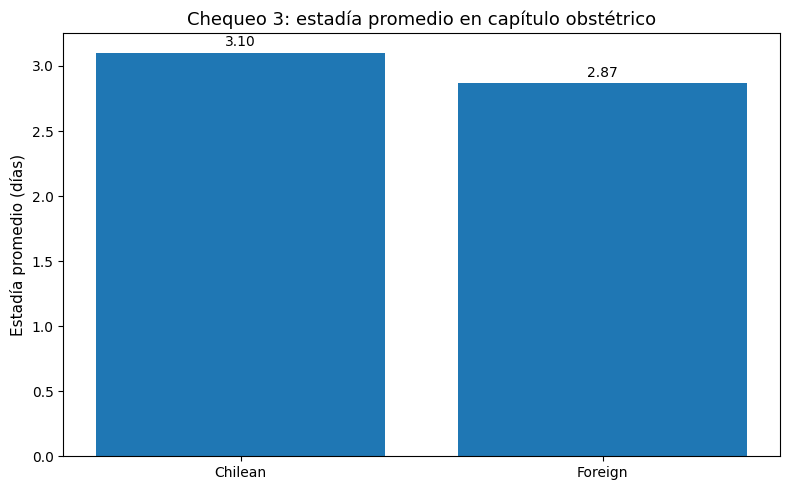

In [19]:
los_sev = ob.groupby("nat_group").agg(
    egresos=("nat_group", "size"),
    los_promedio=("los", "mean"),
    los_mediana=("los", "median"),
    los_max=("los", "max"),
    severidad_promedio=("sev", "mean"),
    severidad_mediana=("sev", "median"),
).reset_index()

display(los_sev)

plt.figure(figsize=(8, 5))
plt.bar(los_sev["nat_group"], los_sev["los_promedio"])
plt.ylabel("Estadía promedio (días)")
plt.title("Chequeo 3: estadía promedio en capítulo obstétrico")
for i, v in enumerate(los_sev["los_promedio"]):
    plt.text(i, v + 0.05, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig(FIGS / "check_los.png", dpi=180)
plt.show()

**Resultado del chequeo 3.** La anomalía no parece explicarse por pocos casos extremos de mayor estadía o severidad. De hecho, dentro del capítulo obstétrico, el grupo extranjero tiene una estadía promedio levemente menor y una severidad promedio similar o menor que el grupo chileno. Esto sugiere que el hallazgo se relaciona más con volumen relativo de egresos obstétricos que con complejidad hospitalaria.

## 8. Qué sugiere y qué no puede decir

Este resultado sugiere que, en Santiago, la demanda hospitalaria asociada a embarazo, parto y puerperio está mucho más concentrada en población extranjera de lo que se esperaría mirando solo la composición comunal. Para política pública, el hallazgo apunta a la necesidad de mirar salud materna, acceso oportuno a controles, continuidad de atención y barreras administrativas o culturales en comunas con alta migración. Sin embargo, este análisis es ecológico y usa egresos, no personas únicas: no permite afirmar que ser extranjera cause más hospitalizaciones obstétricas. Tampoco observa nacimientos fuera del sistema GRD ni atención privada, por lo que debe interpretarse como una señal para profundizar, no como una conclusión causal.

## 9. Conclusión

La anomalía principal es que Santiago no solo tiene alta presencia extranjera: en los egresos hospitalarios de embarazo, parto y puerperio, la participación extranjera llega a cerca de tres cuartos de los casos. El patrón se mantiene en 2022, 2023 y 2024, no aparece con la misma fuerza en los egresos generales y persiste al usar como denominador mujeres de 15 a 49 años. Por eso, el hallazgo es defendible como una anomalía de salud materna a nivel comunal, aunque no debe leerse como causalidad individual. Con una semana más, el siguiente paso sería comparar con comunas vecinas de la Región Metropolitana y separar nacimientos, abortos, complicaciones y controles para distinguir fecundidad, acceso y severidad clínica.